##Estadistica Aplicada

Segundo Examen Parcial

Bryan Alejandro Estrada Rodriguez 1844554

Grupo 42

In [1]:
# Importo las librerias Necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
!pip install lifelines
# importo las librerias especializadas
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullFitter, ExponentialFitter, LogNormalFitter


In [3]:
prestamo = pd.read_csv('https://raw.githubusercontent.com/jimmyzac/Estadistica-Aplicada-FCFM-UANL/main/bases_datos/credit_risk.csv')
prestamo.head()

,saldo_cuenta,meses,historia_crediticia,uso,cantidad,saldo_cuenta_ahorro,años_trabajando,tasa_de_interes,genero_estado_civil,aval,...,activos,edad,planes_de_pago,casa,numero_creditos,situacion_laboral,dependientes_economicos,telefono,extranjero,credito_pagado
0,menor_a_cero,6,no_ha_pagado,TV,1169,NaN,mas_de_7,4,hombre_soltero,NaN,...,bienes_raices,67,NaN,propia,2,gobierno,1,1,1,1
1,cero_a_200,48,pago_algun_credito,TV,5951,menor_100,1_a_4,2,mujer_no_soltera,NaN,...,bienes_raices,22,NaN,propia,1,gobierno,1,0,1,0
2,sin_cuenta,12,no_ha_pagado,colegiaturas,2096,menor_100,4_a_7,2,hombre_soltero,NaN,...,bienes_raices,49,NaN,propia,1,obrero,2,0,1,1
3,menor_a_cero,42,pago_algun_credito,mobiliario,7882,menor_100,4_a_7,2,hombre_soltero,aval,...,seguro_vida,45,NaN,prestada,1,gobierno,2,0,1,1
4,menor_a_cero,24,pago_retrasado,coche_nuevo,4870,menor_100,1_a_4,3,hombre_soltero,NaN,...,sin_activos,53,NaN,prestada,2,gobierno,2,0,1,0


##1. Analisis Exploratorio

a) ¿Cuantas variables y cuantas observaciones tienenla base?


In [4]:
prestamo.count()

saldo_cuenta               1000
meses                      1000
historia_crediticia        1000
uso                        1000
cantidad                   1000
saldo_cuenta_ahorro         817
años_trabajando            1000
tasa_de_interes            1000
genero_estado_civil        1000
aval                         52
años_actual_domicilio      1000
activos                    1000
edad                       1000
planes_de_pago              186
casa                       1000
numero_creditos            1000
situacion_laboral          1000
dependientes_economicos    1000
telefono                   1000
extranjero                 1000
credito_pagado             1000
dtype: int64

In [5]:
variables = prestamo.shape[1]
variables

21

Hay 21 variables y se encuentran 1000 observaciones

b) ¿Cuál es el monto promedio de los créditos otorgados por el banco?

In [6]:
prestamo['cantidad'].mean().round(2)

3271.26

c) ¿Cuál es  el  tiempo  promedio  que  se  tardaron  en  pagar  el  préstamo  los que pagaron el préstamo en su totalidad?

In [7]:
pagado = prestamo.query('credito_pagado == 1')
pagado = pagado['meses'].mean().round(2)
print('El tiempo promedio que se tardan en pagar un prestamo los que pagaron el prestamo en su totalidad es de ',pagado)

El tiempo promedio que se tardan en pagar un prestamo los que pagaron el prestamo en su totalidad es de  19.21


d) ¿Cuál es la tasa de interés promedio otorgada por el banco?

In [8]:
interes = prestamo['tasa_de_interes'].mean().round(2)
print('La tasa de interes promedio de los clientes otorgado por el banco es de ', interes)

La tasa de interes promedio de los clientes otorgado por el banco es de  2.97


e) ¿Cuál es el monto promedio y la tasa de interés promedio de los que ya pagaron?

In [9]:
monto = prestamo.query('credito_pagado == 1')
monto = monto['cantidad'].mean().round(2)
tasa = prestamo.query('credito_pagado ==1')
tasa = tasa['tasa_de_interes'].mean().round(2)
print('El monto promedio y la tasa promedio de los clientes que ya pagarón es de ',monto,'y',tasa,'respectivamente.')

El monto promedio y la tasa promedio de los clientes que ya pagarón es de  2985.46 y 2.92 respectivamente.


f) ¿Cuál es el monto promedio y la tasa de interés promedio de los que no han pagado?

In [10]:
monto = prestamo.query('credito_pagado == 0')
monto = monto['cantidad'].mean().round(2)
tasa = prestamo.query('credito_pagado == 0')
tasa = tasa['tasa_de_interes'].mean().round(2)
print('El monto promedio y la tasa promedio de los clientes que no han pagado es de ',monto,'y',tasa,'respectivamente.')

El monto promedio y la tasa promedio de los clientes que no han pagado es de  3938.13 y 3.1 respectivamente.


## 2. Estime un modelo de Kaplan-meier

a) ¿Cuál es la mediana del tiempo y que significa?

In [11]:
mkaplan = KaplanMeierFitter().fit(prestamo['meses'], prestamo['credito_pagado'])

In [12]:
mkaplan.median_survival_time_

24.0

La mediana del tiempo de supervivencia es 24 meses, lo que significa que la mitad de los clientes tardan 24 meses en pagar en su totalidad el prestamo o que la mitad de los clientes aun no han pagado en su totalidad el prestamo.

b) ¿Es mayor/menor que el tiempo promedio del inciso 1c?

El tiempo es mayor utilizando el modelo KaplanMeier, por lo que el tiempo promedio calculado en el inciso 1c es menor.

## Determine si el riesgo de que el préstamo se pague en su totalidad esconstante,creciente, decreciente, o tipo log-normal respecto al tiempo

In [13]:
exp = ExponentialFitter().fit(prestamo ['meses'], prestamo['credito_pagado'])
wb = WeibullFitter().fit(prestamo ['meses'], prestamo['credito_pagado'])
logn = LogNormalFitter().fit(prestamo ['meses'], prestamo['credito_pagado'])

In [14]:
print('Expoencial:',exp.AIC_.round(2),'  Weibull:', wb.AIC_.round(2),'  Log.normal', logn.AIC_.round(2))

Expoencial: 6157.19   Weibull: 5900.98   Log.normal 5813.75


Text(0.5, 1.0, 'Funcion de Riesgo de LogNormal')

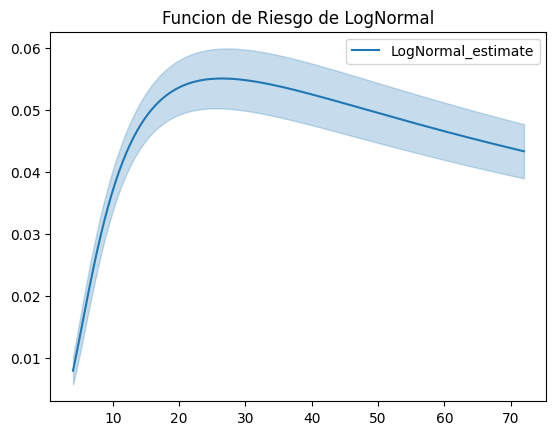

In [15]:
logn.plot_hazard()
plt.title('Funcion de Riesgo de LogNormal')


De acuerdo con el criterio de AIC el "mejor" modelo es Log-Normal, y para saber cuando crece y decrece el riesgo utlizamos hazard_

In [16]:
datos= logn.hazard_
datos.head(168)

,LogNormal_estimate
4.000000,0.007982
4.136273,0.008671
4.272545,0.009375
4.408818,0.010091
4.545090,0.010819
...,...
26.212425,0.055045
26.348697,0.055046
26.484970,0.055046
26.621242,0.055045


El periodo de resgo de quebrar donde es creciente es de 4 al los 26 meses aproximadamente. Por otra parte, el periodo donde el riesgo de quebrar es decreciente es de los 26 meses en adelante.

## 4. Estimar un modelo de Cox para ver qué factores influyen sobre el riesgo de que el préstamo se pague en su totalidad

a) A parte de “tasa de interes” y “cantidad”, elige otras cuatro variables que creas que afectan el riesgo del evento

In [17]:
from lifelines import CoxPHFitter
import seaborn as sns

Las 4 variables que afectan el riesgo del evento

1. Historia crediticia

2. Años trabajando

3. Numero de creditos

4. Dependentes economicos

In [18]:
cox = prestamo[['meses','historia_crediticia','cantidad','años_trabajando','tasa_de_interes','numero_creditos','dependientes_economicos','credito_pagado']]
cox

,meses,historia_crediticia,cantidad,años_trabajando,tasa_de_interes,numero_creditos,dependientes_economicos,credito_pagado
0,6,no_ha_pagado,1169,mas_de_7,4,2,1,1
1,48,pago_algun_credito,5951,1_a_4,2,1,1,0
2,12,no_ha_pagado,2096,4_a_7,2,1,2,1
3,42,pago_algun_credito,7882,4_a_7,2,1,2,1
4,24,pago_retrasado,4870,1_a_4,3,2,2,0
...,...,...,...,...,...,...,...,...
995,12,pago_algun_credito,1736,4_a_7,3,1,1,1
996,30,pago_algun_credito,3857,1_a_4,4,1,1,1
997,12,pago_algun_credito,804,mas_de_7,4,1,1,1
998,45,pago_algun_credito,1845,1_a_4,4,1,1,0


b) Di si cada una de las 6 variables que elegiste, aumentan/disminuyen el riesgo del evento y por qué

*Historia Crediticia*

Si ha pagado algun credito nos dice que si paga y por conciente desminuye el riesgo de que pueda no pagar el prestamo.

*Años trabajandoo*

Si el cliente tiene muchos años trabajando, nos dice que constantemente tiene ingresos y esto puede disminuir el riesgo de que no pague el prestamo.

*Numero de Creditos*

Si el cliente tiene muchos creditos nos dice que puede que aumente el riesgo de que no pague el prestamo por pagar otros creditos.



c) Realiza las transformaciones adecuadas para utilizar las variables en un modelo de cox

In [19]:
# Buscamos datos perdidos
cox.isnull().sum()

meses                      0
historia_crediticia        0
cantidad                   0
años_trabajando            0
tasa_de_interes            0
numero_creditos            0
dependientes_economicos    0
credito_pagado             0
dtype: int64

In [20]:
# Buscamos si hay duplicados en el DataFrame
cox.duplicated().sum()

0

In [21]:
## Verificar que todas las variables son numericas
cox.dtypes

meses                       int64
historia_crediticia        object
cantidad                    int64
años_trabajando            object
tasa_de_interes             int64
numero_creditos             int64
dependientes_economicos     int64
credito_pagado              int64
dtype: object

In [22]:
# Convertimos las Variables que no son numericas
cox = pd.get_dummies(cox,drop_first=True)
cox.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   meses                                   1000 non-null   int64
 1   cantidad                                1000 non-null   int64
 2   tasa_de_interes                         1000 non-null   int64
 3   numero_creditos                         1000 non-null   int64
 4   dependientes_economicos                 1000 non-null   int64
 5   credito_pagado                          1000 non-null   int64
 6   historia_crediticia_pago_algun_credito  1000 non-null   uint8
 7   historia_crediticia_pago_retrasado      1000 non-null   uint8
 8   historia_crediticia_pago_todos          1000 non-null   uint8
 9   historia_crediticia_sin_creditos        1000 non-null   uint8
 10  años_trabajando_4_a_7                   1000 non-null   uint8
 11  años_trabajando_de

In [23]:
# Estadisticas descriptivas
cox.describe()

,meses,cantidad,tasa_de_interes,numero_creditos,dependientes_economicos,credito_pagado,historia_crediticia_pago_algun_credito,historia_crediticia_pago_retrasado,historia_crediticia_pago_todos,historia_crediticia_sin_creditos,años_trabajando_4_a_7,años_trabajando_desempleado,años_trabajando_mas_de_7,años_trabajando_menor_a_1
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,1.407000,1.155000,0.700000,0.530000,0.088000,0.049000,0.040000,0.174000,0.062000,0.253000,0.172000
std,12.058814,2822.736876,1.118715,0.577654,0.362086,0.458487,0.499349,0.283437,0.215976,0.196057,0.379299,0.241276,0.434948,0.377569
min,4.000000,250.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,1365.500000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,18.000000,2319.500000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,24.000000,3972.250000,4.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,72.000000,18424.000000,4.000000,4.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


d) Estima  un  modelo  de  cox  con  las  variables  elegidas  e  interpreta  los coeficientes.

In [24]:
cph = CoxPHFitter().fit(cox,'meses','credito_pagado')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1000 total observations, 300 right-censored observations>
             duration col = 'meses'
                event col = 'credito_pagado'
      baseline estimation = breslow
   number of observations = 1000
number of events observed = 700
   partial log-likelihood = -4039.84
         time fit was run = 2023-10-07 04:50:09 UTC

---
                                         coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                                                      
cantidad                                -0.00       1.00       0.00            -0.00            -0.00                 1.00                 1.00
tasa_de_interes                         -0.43       0.65       0.04            -0.50            -0.35                 0.61                 0.70
numero_creditos                          0.01       1.01       0.09            -0.16             0.18                 0.85                 1.19
dependientes_economicos                  0.07       1.07       0.11            -0.14             0.28                 0.87                 1.32
historia_crediticia_pago_algun_credito  -0.43       0.65       0.10            -0.64            -0.23                 0.53                 0.80
historia_crediticia_pago_retrasado      -0.55       0.58       0.15            -0.84            -0.26                 0.43                 0.77
historia_crediticia_pago_todos          -1.10       0.33       0.24            -1.56            -0.63                 0.21                 0.53
historia_crediticia_sin_creditos        -1.07       0.34       0.27            -1.60            -0.54                 0.20                 0.58
años_trabajando_4_a_7                    0.11       1.11       0.11            -0.11             0.32                 0.90                 1.38
años_trabajando_desempleado             -0.12       0.89       0.17            -0.46             0.23                 0.63                 1.25
años_trabajando_mas_de_7                 0.06       1.06       0.10            -0.14             0.26                 0.87                 1.30
años_trabajando_menor_a_1               -0.08       0.93       0.12            -0.31             0.16                 0.73                 1.17

                                         cmp to      z      p   -log2(p)
covariate                                                               
cantidad                                   0.00 -16.00 <0.005     189.10
tasa_de_interes                            0.00 -11.46 <0.005      98.64
numero_creditos                            0.00   0.09   0.93       0.11
dependientes_economicos                    0.00   0.65   0.51       0.96
historia_crediticia_pago_algun_credito     0.00  -4.15 <0.005      14.86
historia_crediticia_pago_retrasado         0.00  -3.76 <0.005      12.52
historia_crediticia_pago_todos             0.00  -4.64 <0.005      18.14
historia_crediticia_sin_creditos           0.00  -3.98 <0.005      13.81
años_trabajando_4_a_7                      0.00   0.97   0.33       1.59
años_trabajando_desempleado                0.00  -0.66   0.51       0.98
años_trabajando_mas_de_7                   0.00   0.62   0.54       0.90
años_trabajando_menor_a_1                  0.00  -0.64   0.52       0.94
---
Concordance = 0.78
Partial AIC = 8103.68
log-likelihood ratio test = 459.09 on 12 df
-log2(p) of ll-ratio test = 298.82

In [25]:
# Exp(coef) sin redondear
cph.hazard_ratios_

covariate
cantidad                                  0.999617
tasa_de_interes                           0.653295
numero_creditos                           1.008075
dependientes_economicos                   1.072154
historia_crediticia_pago_algun_credito    0.649282
historia_crediticia_pago_retrasado        0.576824
historia_crediticia_pago_todos            0.334118
historia_crediticia_sin_creditos          0.343297
años_trabajando_4_a_7                     1.113112
años_trabajando_desempleado               0.890751
años_trabajando_mas_de_7                  1.064652
años_trabajando_menor_a_1                 0.926134
Name: exp(coef), dtype: float64

## Interpretando cada uno de los resultados

##***Cantidad***

Rechazamos H0

La cantidad del prestamo disminuye el riesgo en un 1% que un cliente pague el prestamo en su totalidad

## ***Tasa de interes***

Rechazamos H0

La tasa de interes disminuye el riesgo en un 34.68% que un cliente pague el prestamo en su totalidad

## ***Numero de creditos***

No rechazamos H0

El numero de creditos no tiene efecto sobre el riesgo de que el cliente pague el prestamo en su totalidad

## ***Dependientes Economicos***

No rechazamos H0

Los dependientes economicos no tienen efecto sobre el riesgo de que el cliente pague el prestamo en su totalidad

## ***Historia crediticia pago algún credito***

Rechazamos H0

La historia crediticia dice que pago algún credito y esto nos dice que  disminuye el riesgo en un 35.08% que el cliente pague el prestamo en su totalidad

## ***Historia crediticia pago retrasado***

Rechazamos H0

La historia crediticia pago retrasado nos dice que disminuye el riesgo en un 42.32% que el cliente pague el prestamo en su totalidad

## ***Historia crediticia pago todos***

Rechazamos H0

La historia crediticia pago todos nos dice que disminuye el riesgo en un 66.59% que el cliente pague el prestamo en su totalidad


## ***Historia crediticia sin creditos***

Rechazamos H0

La historia crediticia sin creditos nos dice que disminuye el riesgo en un 65.68% que el cliente pague el prestamo en su totalidad

## ***Años trabajando 4 a 7 ***

No eechazamos H0

Trabajando de 4 a 7 años no tienen efecto sobre el riesgo de que el cliente pague el prestamo en su totalidad

## ***Años trabajando desempleado***

No eechazamos H0

Estar desempleado no tienen efecto sobre el riesgo de que el cliente pague el prestamo en su totalidad

## ***Años trabajando mas de 7***

No eechazamos H0

Haber trabajado por mas de 7 años no tienen efecto sobre el riesgo de que el cliente pague el prestamo en su totalidad

## ***Años trabajando menor a 1***

No eechazamos H0

Haber trabajado por menos de 1 años no tienen efecto sobre el riesgo de que el cliente pague el prestamo en su totalidad

## 5. Con  base  en  los  cálculos  realizados,  redacta  un  comentario integral de  por  lo menos  250 palabras que  resuma  el  análisis,  reflexiones  y  recomendaciones sobre la política de otorgamiento de créditos en el Banco de la Ilusión.

El análisis realizado involucra la construcción de un modelo de riesgo utilizando el modelo de regresión de riesgos proporcionales de Cox (CoxPH) en un conjunto de datos relacionados con préstamos o créditos. Se han seleccionado un conjunto de variables que se cree que afectan el riesgo de que un cliente pague el préstamo en su totalidad.
1. Cantidad del Préstamo: El coeficiente para esta variable es menor que 1, lo que significa que una mayor cantidad de préstamo disminuye el riesgo de que el cliente no pague en su totalidad. Esto puede deberse a que los clientes con préstamos más grandes pueden tener más recursos financieros para cumplir con sus pagos. A continuación, se presenta una interpretación detallada de los resultados:

2. Tasa de Interés: La tasa de interés tiene un efecto significativo en la reducción del riesgo de que el cliente no pague en su totalidad. Una tasa de interés más alta disminuye el riesgo en un 34.68%. Esto sugiere que los clientes con tasas de interés más bajas tienen una mayor probabilidad de pagar sus préstamos.

3. Número de Créditos: El coeficiente para esta variable es cercano a 1, lo que indica que el número de créditos no tiene un efecto significativo en el riesgo de pago del préstamo. En otras palabras, tener más créditos no aumenta ni disminuye considerablemente el riesgo.

4. Dependientes Económicos: Al igual que el número de créditos, los dependientes económicos no tienen un efecto significativo en el riesgo de pago del préstamo. Esto sugiere que la situación familiar no influye de manera importante en la capacidad de pago del cliente.

5. Historia Crediticia: La historia crediticia tiene un impacto significativo en el riesgo de pago del préstamo. Aquellos clientes que tienen un historial de pago puntual o pagaron todos sus créditos en el pasado tienen un menor riesgo de no pagar en su totalidad.

6. Años Trabajando: La duración del empleo actual no parece tener un efecto significativo en el riesgo de pago del préstamo.

El análisis muestra que factores como la cantidad del préstamo, la tasa de interés y la historia crediticia son importantes para determinar el riesgo de impago de un préstamo. Estos resultados pueden ser útiles para tomar decisiones crediticias más informadas y gestionar el riesgo crediticio de manera más efectiva. Sin embargo, es importante recordar que estos resultados se basan en el conjunto de datos y el contexto específico, y pueden variar en diferentes situaciones. Por lo tanto, es esencial considerar estos resultados con cautela y en el contexto adecuado.